## Deducción de la Función de Transferencia $H(s)$

> **Nota:** Debido a que el nodo de entrada $PA$ está conectado directamente al nodo $V_L$ mediante un conductor ideal, ambos voltajes son equivalentes ($V_L = PA$ y $V_L(s) = PA(s)$).

### 1. Impedancia del Primer Bloque ($Z_1$)
Corresponde al arreglo en paralelo de la resistencia $R_c$ y el inductor $L$:

$$Z_1(s) = R_c \parallel sL = \frac{R_c \cdot sL}{R_c + sL}$$

### 2. Impedancia del Segundo Bloque ($Z_2$)
Corresponde al arreglo en paralelo del capacitor $C$ y la resistencia de carga $R_p$:

$$Z_2(s) = R_p \parallel \frac{1}{sC} = \frac{R_p \cdot \frac{1}{sC}}{R_p + \frac{1}{sC}} = \frac{R_p}{1 + s C R_p}$$

### 3. Impedancia Total del Circuito ($Z_{\text{total}}$)
Como ambos bloques están conectados en serie, la impedancia equivalente vista desde la entrada es la suma de $Z_1(s)$ y $Z_2(s)$:

$$Z_{\text{total}}(s) = Z_1(s) + Z_2(s) = \frac{R_c s L}{R_c + s L} + \frac{R_p}{1 + s C R_p}$$

---

### 4. Ecuación para el Voltaje $V_L$ ($PA$)
Aplicando la Ley de Ohm generalizada en el dominio de Laplace, el voltaje $V_L(s)$ (equivalente a $PA(s)$) en función del flujo de entrada $Q(s)$ es:

$$V_L(s) = PA(s) = Q(s) \cdot Z_{\text{total}}(s) = Q(s) \left( \frac{R_c s L}{R_c + s L} + \frac{R_p}{1 + s C R_p} \right)$$

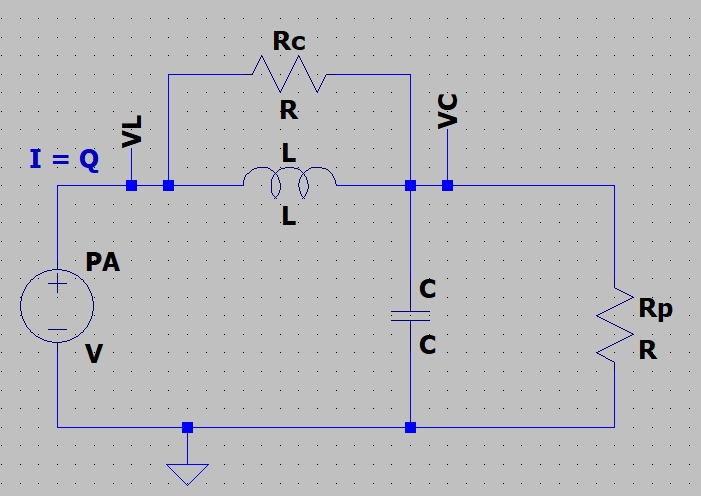
---

### 5. Función de Transferencia $H(s)$
La función de transferencia $H(s)$ se define como la relación entre la respuesta de voltaje $V_L(s)$ (o $PA(s)$) y la entrada de corriente $Q(s)$:

$$H(s) = \frac{V_L(s)}{Q(s)} = \frac{PA(s)}{Q(s)} = \frac{R_c s L}{R_c + s L} + \frac{R_p}{1 + s C R_p}$$

Agrupando los términos en una sola fracción con el mínimo común denominador, se obtiene la **forma polinomial canónica**:

$$H(s) = \frac{(R_c R_p L C) \, s^2 + (R_c L + R_p L) \, s + R_c R_p}{(R_p L C) \, s^2 + (R_c R_p C + L) \, s + R_c}$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import scipy.signal as signal

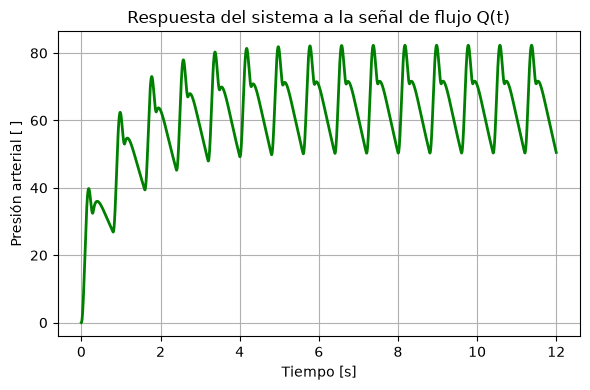

In [4]:
# Parámetros
Q_max = 500.0  # Flujo máximo
Ts = 0.3       # Tiempo de sístole [segundos]
Td = 0.5       # Tiempo de diástole [segundos]
T = Ts + Td    # Periodo total de un ciclo cardíaco (0.8 s ≈ 75 bpm)
Rc = 0.055       # Resistencia de la arteria
Rp = 0.7       # Resistencia periférica
L = 0.005       # Inductancia
C = 1.5       # Capacitancia



numerador=[(Rc*Rp*L*C),(Rc*L+Rp*L), (Rc*Rp)]
denominador=[(Rp*L*C),(Rc*Rp*C+L), Rc]


sys_tf = signal.TransferFunction(numerador, denominador)



time = np.linspace(0, 12, 3000)
# Tiempo relativo dentro de cada ciclo (de 0 a T)
t_cycle = time % T

# Señal Q(t) periódica
Q = np.where(t_cycle <= Ts, Q_max * (np.sin(np.pi * t_cycle / Ts))**2, 0)

t_out, y_out, _ = signal.lsim(sys_tf, Q, T=time)

plt.figure(figsize=(6, 4))
plt.plot(t_out, y_out, color='green', linewidth=2)
plt.title('Respuesta del sistema a la señal de flujo Q(t)')
plt.xlabel('Tiempo [s]')
plt.ylabel('Presión arterial [ ]')
plt.grid(True)
plt.tight_layout()
plt.show()